In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

DATA_DIR = Path("..") / "data" / "raw" / "training"
IMAGES_DIR = DATA_DIR / "image_2"
LABELS_DIR = DATA_DIR / "label_2"

# Целевые классы для детекции. Остальные классы KITTI в проекте не будут детектироваться.
TARGET_CLASSES = ["Car", "Pedestrian", "Cyclist", "Truck"]

In [2]:
def read_label(label_path):
    """Читает один файл аннотации KITTI.
    Возвращает список объектов: (класс, x1, y1, x2, y2).
    Берем только поля классы и координаты box (прямоугольника) в формате KITTI"""
    objects = []
    with open(label_path) as f:
        for line in f:
            parts = line.split()
            cls = parts[0]
            x1, y1, x2, y2 = map(float, parts[4:8])
            objects.append((cls, x1, y1, x2, y2))
    return objects

In [3]:
# Пример вывода необходимых данных из файла аннотации
read_label(LABELS_DIR / "000000.txt")

[('Pedestrian', 712.4, 143.0, 810.73, 307.92)]

{'Pedestrian': 4487,
 'Truck': 1094,
 'Car': 28742,
 'Cyclist': 1627,
 'DontCare': 11295,
 'Misc': 973,
 'Van': 2914,
 'Tram': 511,
 'Person_sitting': 222}

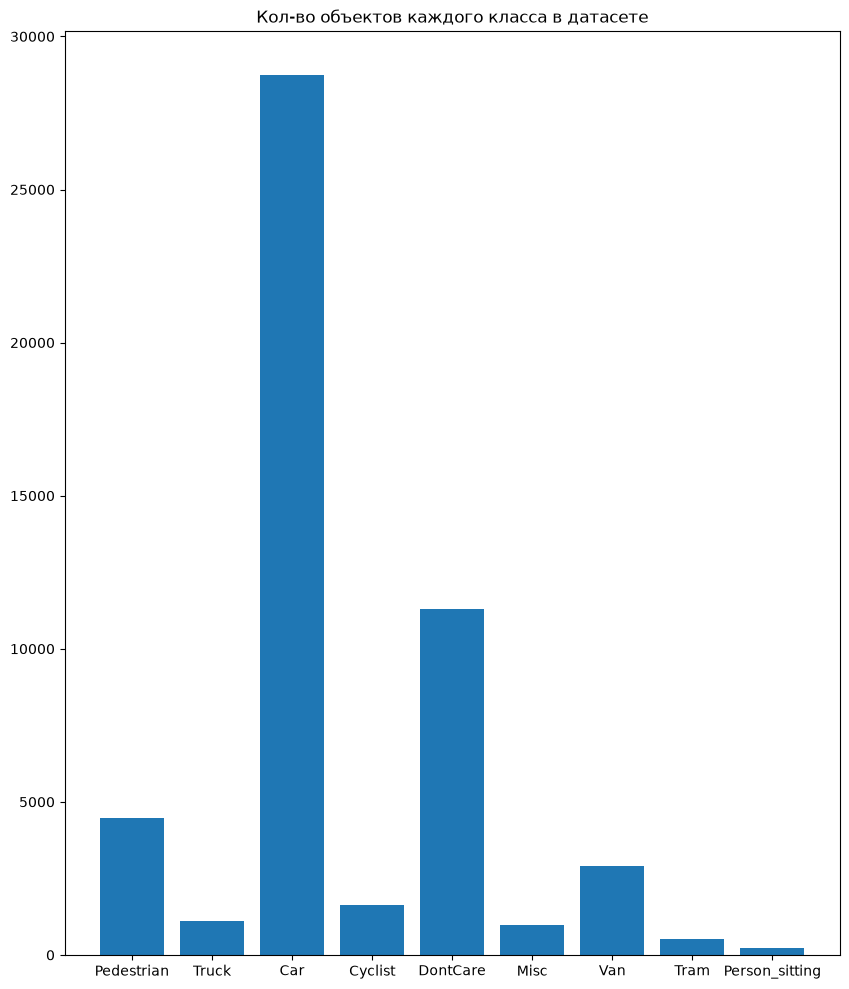

In [4]:
# Подсчет кол-ва объектов каждого класса в датасете и визуализация
class_counts = {}
for label_file in LABELS_DIR.glob("*.txt"):
    objects = read_label(label_file)
    for obj in objects:
        cls = obj[0]
        if cls not in class_counts:
            class_counts[cls] = 0
        class_counts[cls] += 1

display(class_counts)

plt.figure(figsize = (10,12))
plt.bar(class_counts.keys(), 
        class_counts.values()
        )
plt.title('Кол-во объектов каждого класса в датасете')
plt.show()

In [5]:
def show_image_with_boxes(image_id):
    """Открывает картинку по её номеру и рисует все боксы из метки.
    image_id — строка вида '000000'."""
    image_path = IMAGES_DIR / f"{image_id}.png"
    label_path = LABELS_DIR / f"{image_id}.txt"

    image = Image.open(image_path)
    objects = read_label(label_path)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(image)

    for cls, x1, y1, x2, y2 in objects:
        if cls not in TARGET_CLASSES:
            continue
        width = x2 - x1
        height = y2 - y1
        rect = patches.Rectangle((x1, y1), width, height,
                                 linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, cls, color="red", fontsize=9)

    ax.axis("off")
    plt.show()

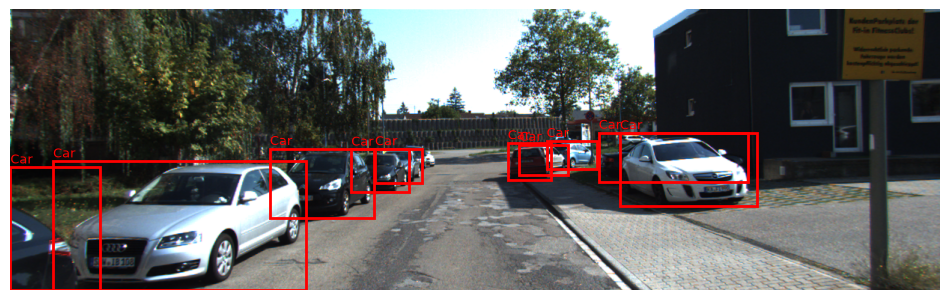

In [6]:
# Пример вывода картинки с наложенными боксами (детекциями) только нужных классов
show_image_with_boxes("000120")

In [7]:
# Проверка качества боксов. Поиск аномальных боксов
bad_boxes = 0
tiny_boxes = 0
total_boxes = 0

for label_file in LABELS_DIR.glob("*.txt"):
    for cls, x1, y1, x2, y2 in read_label(label_file):
        if cls not in TARGET_CLASSES:
            continue
        total_boxes += 1
        # бокс с нулевой или отрицательной площадью (аннотация некорректна)
        if x2 <= x1 or y2 <= y1:
            bad_boxes += 1
        # очень маленький бокс
        elif (x2 - x1) < 10 or (y2 - y1) < 10:
            tiny_boxes += 1

print(f"Всего боксов (целевые классы): {total_boxes}")
print(f"Битых боксов (нулевая/отрицательная площадь): {bad_boxes}")
print(f"Очень маленьких боксов: {tiny_boxes}")

Всего боксов (целевые классы): 35950
Битых боксов (нулевая/отрицательная площадь): 0
Очень маленьких боксов: 218
